provo a rigenerare il grafico fatto in foto per poi decidere quale tenere

questa foto è: 
drive/lab/foto_calibrazione/minerva_fluctuation/F0002CH1.csv  +
drive/lab/foto_calibrazione/minerva_fluctuation/F0002CH3.csv


In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

default_dir = str(Path(".").absolute()).split("/Lab-muons")[0]+"/Lab-muons/"
universal_dir = lambda path: default_dir + path

In [7]:
df = pd.read_csv(universal_dir('/Photo/F0007CH1.csv'), skiprows= 20, sep = ',', usecols=[3, 4], header= None)
df2 = pd.read_csv(universal_dir('/Photo/F0002CH3.CSV'), skiprows= 20, sep = ',', usecols=[3, 4], header= None)
df.columns = ['x', 'y']
df2.columns = ['x', 'y']
# print (df)

<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_33457/3443156908.py:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.xlabel('Time [$ \mu s $]')


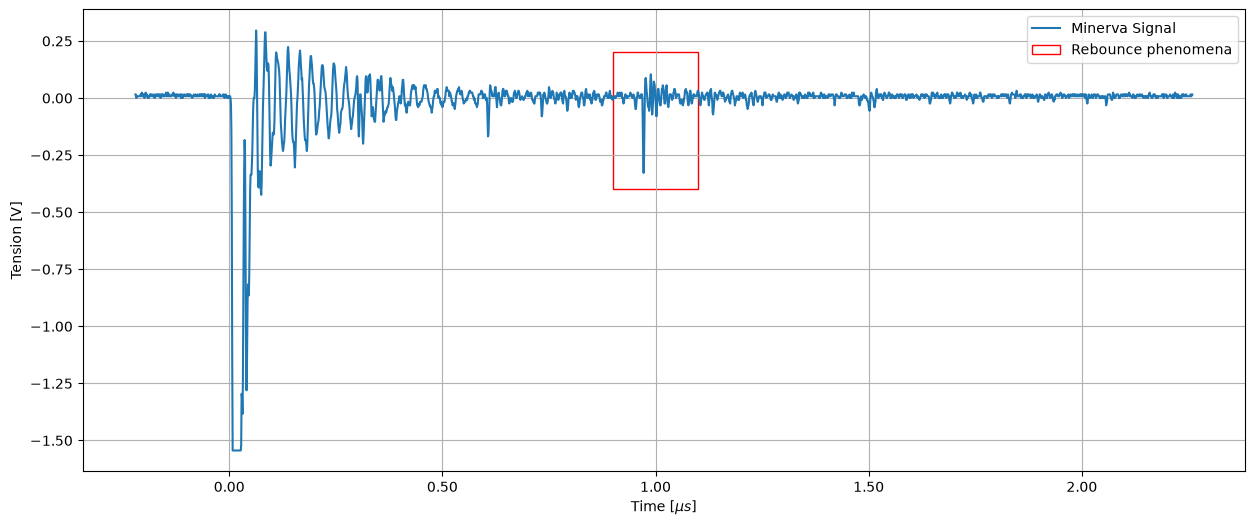

In [23]:
from matplotlib.patches import Rectangle

plt.figure(figsize = (15, 6))
plt.plot(df['x'][:], df['y'][:], label = 'Minerva Signal')
# plt.plot(df2['x'], df2['y'], label = 'Minerva signal')
plt.xlabel('Time [$ \mu s $]')
plt.ylabel('Tension [V]')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x*1e6:.2f}'))


ax = plt.gca()
ax.add_patch(
    Rectangle(
        (0.9e-6, -0.4),
        0.2e-6,
        0.6,
        fill=False,
        edgecolor='red',
        linewidth=1,
        label='Rebounce phenomena'
    )
)

plt.grid()
plt.legend()
plt.savefig("minerva_signal.pdf" , format = "pdf")